In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from  matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MaxNLocator
import numpy as np
lightblue , darkblue, lightgreen, darkgreen, pink =  '#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99'

# 1. Reading in libraries

In [4]:
gcn4 = pd.read_csv("../data/library_boxplots/Gcn4OrthologData_ToShare_20240930.csv")
gcn4["protein sequence"] = gcn4["ADseq"]
gcn4

,Unnamed: 0,ADseq,Name,ArrayDNA,Activity_BioRepA_BYS4,Activity_BioRepB_BYS4,TotalReads_BioRepA_BYS4,TotalReads_BioRepB_BYS4,BioRep_A_GFP_TotalReads,BioRep_A_GFP,...,F..D,MF.Y..L,M..Y..L,SP,[WFYL]...[WFYL][WFYL],WFL,WFYLM,WF,TotalReads_SCglucose,protein sequence
0,0,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQA,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_1,ATGGCTTTGAGAATTGAAGTTTATAATAGAATTGAATCTTCTACTG...,62100.529409,39598.983661,1098.0,2857.0,NaN,NaN,...,0,0,0,0,0,4,7,1,3955.0,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQA
1,1,EVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQ,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_6,GAAGTTTATAATAGAATTGAATCTTCTACTGCTTCTACTGCTTTGC...,NaN,22153.464394,NaN,43534.0,NaN,NaN,...,0,0,0,0,0,3,6,1,NaN,EVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQ
2,2,IESSTASTALQRQDLRYTFRSNARAASGQANANYQAFTAG,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_11,ATTGAATCTTCTACTGCTTCTACTGCTTTGCAAAGACAAGATTTGA...,35362.047143,16461.733704,90903.0,3102.0,1797.0,530.633638,...,0,0,0,0,0,4,6,2,94005.0,IESSTASTALQRQDLRYTFRSNARAASGQANANYQAFTAG
3,3,ASTALQRQDLRYTFRSNARAASGQANANYQAFTAGSALNG,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_16,GCTTCTACTGCTTTGCAAAGACAAGATTTGAGATATACATTTAGAT...,34961.675584,9931.871718,204600.0,226.0,3974.0,709.844542,...,0,0,0,0,0,5,7,2,204826.0,ASTALQRQDLRYTFRSNARAASGQANANYQAFTAGSALNG
4,4,QRQDLRYTFRSNARAASGQANANYQAFTAGSALNGPSLPA,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_21,CAAAGACAAGATTTGAGATATACATTTAGATCTAATGCTAGAGCTG...,55288.447568,47714.348847,1128.0,43923.0,NaN,NaN,...,0,0,0,0,0,5,7,2,45051.0,QRQDLRYTFRSNARAASGQANANYQAFTAGSALNGPSLPA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20726,20726,AKVDTEEEDKTMVDSTSLSWEDLFDFESYSTDLIASINPD,Gnc4Lib_Kappa_HIGH_0,GCTAAAGTTGATACTGAAGAAGAAGATAAGACTATGGTTGATTCTA...,261745.694159,261913.808975,22275.0,53393.0,2685.0,8782.000000,...,0,0,0,0,0,6,8,3,75668.0,AKVDTEEEDKTMVDSTSLSWEDLFDFESYSTDLIASINPD
20727,20727,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR,Gnc4Lib_Disorder_HIGH_0,TCTACTGATTATACTCCAATGTTTGAATATGAAACTTATGAAGATA...,261606.121575,261215.289071,3225.0,23456.0,414.0,8782.000000,...,1,0,0,0,0,6,10,4,26681.0,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR
20728,20728,MTDSTPMFEYELTENNSKEWTSLFDTDIPVTTDDESLADK,Gnc4Lib_Disorder_HIGH_0,ATGACTGATTCTACTCCAATGTTTGAATATGAATTGACTGAGAATA...,158954.046399,146643.694216,64713.0,46036.0,10295.0,4506.455793,...,1,0,0,0,0,6,9,3,110749.0,MTDSTPMFEYELTENNSKEWTSLFDTDIPVTTDDESLADK
20729,20729,STDSTPMFEYQNLENNSKEWTSLFDNDIPVTTDNVSLADK,Gnc4Lib_Charge_HIGH_0,TCTACTGATTCTACTCCAATGTTTGAATATCAGAATTTGGAGAATA...,120532.321833,105862.794762,4430.0,53110.0,452.0,3363.151895,...,1,1,1,0,0,6,8,3,57540.0,STDSTPMFEYQNLENNSKEWTSLFDNDIPVTTDNVSLADK


In [5]:
paddle_xl = pd.ExcelFile("../data/library_boxplots/PADDLE_elife-68068-fig1-data1-v3.xlsx")

# Loading in all tested sequences
paddle = []

for sheet_name in paddle_xl.sheet_names[1:]:
    print(sheet_name)


for sheet_name in ["TF tiles, see Fig 1", "AD mutants, see Fig 2", "53 aa mutants, see Fig 2,4,7"]:
    df = paddle_xl.parse(sheet_name)
    df = df[["Unnamed: 0", "protein sequence", "Z score"]]
    paddle.append(df)

paddle = pd.concat(paddle)
paddle = paddle.reset_index(drop = True)
paddle

TF tiles, see Fig 1
AD mutants, see Fig 2
53 aa mutants, see Fig 2,4,7
cAD muts and 9mers, see Fig 3,4
Nuclear proteins, see Fig 7


,Unnamed: 0,protein sequence,Z score
0,A_controls_GAL4:147-199-1,SIDSAAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPN...,9.943363
1,A_controls_GAL4:147-199-2,SIDSAAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPN...,9.921760
2,A_controls_GAL4:147-199-3,SIDSAAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPN...,10.223345
3,A_controls_GAL4:147-199-4,SIDSAAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPN...,10.453645
4,A_controls_GAL4:147-199-5,SIDSAAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPN...,9.840524
...,...,...,...
13522,D_random_A50,YNPNYDTLSISSTCAVRKGNSLECSKEYFTDHELNYMSLEPRVERG...,-0.032684
13523,D_random_A6,QCADIDNPRRFLIRSLKDNSKNAYPKDVTKLFRRVYMIPFFGTSKS...,-0.637923
13524,D_random_A7,GFSWKLGDINAMKTAAVHCESGKLPDPSKLVALLLLSRLSNKEAIK...,-0.424991
13525,D_random_A8,RAAYNSASALDCWTEAPSIRVRAPEMYPGCGGTATAQSQMIQDVVK...,0.320329


In [6]:
delrosso_1 = pd.read_excel("../data/library_boxplots/DelRosso_41586_2023_5906_MOESM5_ESM.xlsx")
#CRTF tiling library sequences and enrichment scores from the FLAG protein expression screen, minCMV, pEF and PGK promoter screens, and the validation screens.

delrosso_4 = pd.read_excel("../data/library_boxplots/DelRosso_41586_2023_5906_MOESM8_ESM.xlsx")
#AD mutants library sequences and enrichment scores from the FLAG protein expression screen and minCMV promoter screen.


delrosso_1 = delrosso_1.rename(columns = {"Protein Sequence" : "protein sequence"})
delrosso_4 = delrosso_4.rename(columns = {"Protein Sequence" : "protein sequence"})

all_delrosso = delrosso_1[list(set(delrosso_4.columns) - set(['ID', 'batch retest hit', 'Sublibrary']))]
all_delrosso = pd.concat([all_delrosso, delrosso_4])
all_delrosso = all_delrosso.reset_index(drop = True)
all_delrosso

,Avg_minCMV,R1_minCMV,Hit FLAG,Standard Error_minCMV,R1_FLAG,Avg_FLAG,Hit minCMV,label,protein sequence,R2_minCMV,Standard Error_FLAG,extended DNA Sequence,R2_FLAG,ID,batch retest hit,Sublibrary
0,1.729123,1.449921,Hit,0.279202,1.327846,1.097958,NaN,CRTiles;ENSG00000148584;A1CF;0;1;80;EpiFactors...,MESNHKSGDGLSGTQKEAALRALVQRTGYSLVQENGQRKYGGPPPG...,2.008325,0.229888,CAgAGATTCAACCGTCCTGCGTCTCTctccATGGAGTCAAACCACA...,0.868070,NaN,NaN,NaN
1,3.092911,5.372556,Hit,2.279646,-1.811731,-1.085594,NaN,CRTiles;ENSG00000148584;A1CF;1;11;90;EpiFactor...,LSGTQKEAALRALVQRTGYSLVQENGQRKYGGPPPGWDAAPPERGC...,0.813265,0.726137,CAgAGATTCAACCGTCCTGCGTCTCTctccCTGAGCGGAACACAAA...,-0.359457,NaN,NaN,NaN
2,4.513614,4.241204,Not Hit,0.272410,-2.452639,-2.433042,NaN,CRTiles;ENSG00000148584;A1CF;2;21;100;EpiFacto...,RALVQRTGYSLVQENGQRKYGGPPPGWDAAPPERGCEIFIGKLPRD...,4.786024,0.019598,CAgAGATTCAACCGTCCTGCGTCTCTctccCGCGCTCTGGTGCAAC...,-2.413444,NaN,NaN,NaN
3,NaN,NaN,Not Hit,NaN,-6.425872,-3.725376,NaN,CRTiles;ENSG00000148584;A1CF;3;31;110;EpiFacto...,LVQENGQRKYGGPPPGWDAAPPERGCEIFIGKLPRDLFEDELIPLC...,NaN,2.700497,CAgAGATTCAACCGTCCTGCGTCTCTctccCTGGTCCAAGAGAACG...,-1.024879,NaN,NaN,NaN
4,6.285598,6.285598,NaN,NaN,NaN,NaN,NaN,CRTiles;ENSG00000148584;A1CF;4;41;120;EpiFacto...,GGPPPGWDAAPPERGCEIFIGKLPRDLFEDELIPLCEKIGKIYEMR...,NaN,NaN,CAgAGATTCAACCGTCCTGCGTCTCTctccGGTGGGCCTCCGCCCG...,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125886,-2.353995,-2.570874,1.0,0.216879,1.450529,1.373581,0.0,mP;delScanAD;TFTiles;ENSG00000100146;SOX10;26;...,SMGEGGKPHIDFGNVDIGEISHEVMSNMETFDVAELDQYLPPNGHP...,-2.137116,0.076947,TTAAACCGGCCAACATACCCGTCTCActccTCAATGGGCGAAGGCG...,1.296634,SOX10;26,NaN,delScanAD
125887,-0.700967,-0.248523,1.0,0.452444,1.066724,1.503462,1.0,mP;delScanAD;TFTiles;ENSG00000100146;SOX10;26;...,SMGEGGKPHIDFGNVDIGEISHEVMSNMETFDVAELDQYLPPNGHP...,-1.153411,0.436739,TTAAACCGGCCAACATACCCGTCTCActccTCAATGGGAGAAGGCG...,1.940201,SOX10;26,NaN,delScanAD
125888,0.126503,-0.502563,1.0,0.629067,4.549330,2.822870,1.0,mP;delScanAD;TFTiles;ENSG00000100146;SOX10;26;...,SMGEGGKPHIDFGNVDIGEISHEVMSNMETFDVAELDQYLPPNGHP...,0.755570,1.726460,TTAAACCGGCCAACATACCCGTCTCActccTCAATGGGAGAAGGCG...,1.096409,SOX10;26,NaN,delScanAD
125889,-0.663884,-1.387943,1.0,0.724060,1.193516,1.520610,1.0,mP;delScanAD;TFTiles;ENSG00000100146;SOX10;26;...,SMGEGGKPHIDFGNVDIGEISHEVMSNMETFDVAELDQYLPPNGHP...,0.060176,0.327094,TTAAACCGGCCAACATACCCGTCTCActccTCAATGGGAGAAGGCG...,1.847704,SOX10;26,NaN,delScanAD


In [7]:
morffy = pd.read_excel("../data/library_boxplots/Morffy_41586_2024_7707_MOESM2_ESM.xlsx")
morffy = morffy.rename(columns = {"Fragment Sequence" : "protein sequence"})
morffy 

,Sub Library,Fragment Name,protein sequence,Gene Model,ATG Number,Start Position,PADI Score,TF Family,Mean Disorder,AD Subtype,...,CountN,CountP,CountQ,CountR,CountS,CountT,CountV,CountW,CountY,Aromatics
0,Lib1,AT1G01010.1_1,MEDQVGFGFRPNDEELVGHYLRNKIEGNTSRDVEVAISEV,AT1G01010.1,AT1G01010,1,1.004699,NAC,0.254442,1.0,...,3,1,1,3,2,1,5,0,1,5
1,Lib1,AT1G01010.1_11,PNDEELVGHYLRNKIEGNTSRDVEVAISEVNICSYDPWNL,AT1G01010.1,AT1G01010,11,0.575876,NAC,0.131235,NaN,...,5,2,0,2,3,1,4,1,2,6
2,Lib1,AT1G01010.1_21,LRNKIEGNTSRDVEVAISEVNICSYDPWNLRFQSKYKSRD,AT1G01010.1,AT1G01010,21,-0.300407,NAC,0.104265,NaN,...,4,1,1,4,5,1,3,1,2,6
3,Lib1,AT1G01010.1_31,RDVEVAISEVNICSYDPWNLRFQSKYKSRDAMWYFFSRRE,AT1G01010.1,AT1G01010,31,0.105372,NAC,0.105342,NaN,...,2,1,1,5,5,0,3,2,3,9
4,Lib1,AT1G01010.1_41,NICSYDPWNLRFQSKYKSRDAMWYFFSRRENNKGNRQSRT,AT1G01010.1,AT1G01010,41,-0.167147,NAC,0.240860,NaN,...,5,1,2,6,5,1,0,2,3,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69568,Lib10,ATMG00940.1_91,SDFVVKAEDVEASMAIFWTPGTRVKMAMETEDSSRITWFQ,ATMG00940.1,ATMG00940,91,-0.139281,Other,0.084480,NaN,...,0,1,1,2,4,4,4,2,0,5
69569,Lib10,ATMG00940.1_101,EASMAIFWTPGTRVKMAMETEDSSRITWFQGIVFYTYQET,ATMG00940.1,ATMG00940,101,-0.064551,Other,0.104625,NaN,...,0,1,2,2,3,6,2,2,2,7
69570,Lib10,ATMG00940.1_111,GTRVKMAMETEDSSRITWFQGIVFYTYQETGPWRGSPWNS,ATMG00940.1,ATMG00940,111,-0.410777,Other,0.159452,NaN,...,1,2,2,3,4,5,2,3,2,7
69571,Lib10,ATMG00940.1_121,EDSSRITWFQGIVFYTYQETGPWRGSPWNSFRYKIPFTIP,ATMG00940.1,ATMG00940,121,0.329820,Other,0.204375,NaN,...,1,4,2,3,4,4,1,3,3,10


In [8]:
erijman = pd.read_csv("../data/library_boxplots/Erijman_1-s2.0-S1097276520302628-mmc2.csv")
erijman = erijman.rename(columns = {"sequence" : "protein sequence"})
erijman

,#,protein sequence,background,bin1,bin2,bin3,bin4,enrichmen_score,AD_set
0,0,MFGDVSDDSGDGFYDEIIALIVSADDKTRT,2,0,17,10,0,3.08,AD_positive
1,1,RVGIGDGGIAIVDSVFDNLDNFFVNILAMM,1,2,0,17,106,5.60,AD_positive
2,2,ECDSPREAFDVNDYYNWGEVVKGGAIGMLS,0,0,19,31,0,4.91,AD_positive
3,3,IGDCVFNATSLYLYEDSNDEWNVLVWKAGE,1,0,1,46,0,4.30,AD_positive
4,4,AYRFLATEWARDSSALFCEFGIESCRYGWT,5,11,58,56,1,3.94,AD_positive
...,...,...,...,...,...,...,...,...,...
1054330,1054330,SGELVTLNEECSGPEKAIRGSIDAAKRSTE,1,0,0,0,0,-5.30,AD_negative
1054331,1054331,SDTDRCHNWDSSYFWGSSWHTSVPRLACCW,2,0,0,0,0,-5.70,AD_negative
1054332,1054332,STDVAATYPNSATRTARRAGETSIEDDGYC,1,0,0,0,0,-5.30,AD_negative
1054333,1054333,NEWGVDVVVVVNCVIVPSVLSLSRLERWLK,1,0,0,0,0,-5.30,AD_negative


In [9]:
staller_2018 = pd.read_csv("../data/library_boxplots/Staller_2018_Supplemental_DataTable1_ActivityData.csv", index_col = 0)
staller_2018 = staller_2018.rename(columns = {"ActivationDomainSeq" : "protein sequence",
                                             "ActivityCompleteMediaReplicate1_Normalized" : "ActivRep1_Norm"})
staller_2018

,protein sequence,ActivRep1_Norm,ActivityCompleteMediaReplicate2_Normalized,Induction,ActivityCompleteMediaReplicate1_Raw,ActivityCompleteMediaReplicate2_Raw,ActivityAAStarvation_Raw,MutationClass,Charge,Hydrophobicity,Kappa,Disorder,HighStringencySet,VeryHighStringencySet,mCherryOnly_Raw
Index,,,,,,,,,,,,,,,
0,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIES,0.088717,0.041491,1.580204,53062.14015,47825.67426,83848.99148,Control,-10,0.413889,0.147096,0.550821,True,True,660.806508
1,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIES,NaN,NaN,NaN,0.00000,0.00000,0.00000,Control,-10,0.413889,0.147096,0.550821,False,False,0.000000
2,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIES,-0.087674,-0.145413,1.691536,46955.43323,42014.33786,79426.79639,Control,-10,0.413889,0.147096,0.550821,True,True,682.531509
3,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIES,-0.007988,-0.042719,1.546319,49621.94393,45114.01223,76731.33364,Control,-10,0.413889,0.147096,0.550821,True,True,634.149967
4,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIES,NaN,NaN,NaN,0.00000,0.00000,0.00000,Control,-10,0.413889,0.147096,0.550821,False,False,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6495,DKAELMNLSPFAETISTDNWSNLFEKPTSTYVDDDEVESDISDT,NaN,NaN,NaN,0.00000,0.00000,0.00000,Kappa,-10,0.413889,0.314448,0.550026,False,False,0.000000
6496,IALSQPETIPAKEISVPPSPAVGKSASPAPSPAPSKSGVKHSTV,0.352245,0.264259,1.174391,63696.34587,55811.15865,74804.42351,ChopOrthologs,2,0.479293,0.268806,0.760082,True,False,353.827773
6497,SLVIPNTSFLPTPVIEDAKLNSKKSSAGSVQKKSDKLDRLGVIS,-0.229211,-0.302345,1.177644,42567.58315,37683.94614,50129.46275,ChopOrthologs,3,0.474495,0.197048,0.416135,True,True,504.847299


---

# 2. Plotting

In [10]:
gcn4 = gcn4.rename(columns = {"Activity_SCglucose" : "Gcn4 ortholog activity"})
gcn4

,Unnamed: 0,ADseq,Name,ArrayDNA,Activity_BioRepA_BYS4,Activity_BioRepB_BYS4,TotalReads_BioRepA_BYS4,TotalReads_BioRepB_BYS4,BioRep_A_GFP_TotalReads,BioRep_A_GFP,...,F..D,MF.Y..L,M..Y..L,SP,[WFYL]...[WFYL][WFYL],WFL,WFYLM,WF,TotalReads_SCglucose,protein sequence
0,0,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQA,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_1,ATGGCTTTGAGAATTGAAGTTTATAATAGAATTGAATCTTCTACTG...,62100.529409,39598.983661,1098.0,2857.0,NaN,NaN,...,0,0,0,0,0,4,7,1,3955.0,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQA
1,1,EVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQ,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_6,GAAGTTTATAATAGAATTGAATCTTCTACTGCTTCTACTGCTTTGC...,NaN,22153.464394,NaN,43534.0,NaN,NaN,...,0,0,0,0,0,3,6,1,NaN,EVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQ
2,2,IESSTASTALQRQDLRYTFRSNARAASGQANANYQAFTAG,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_11,ATTGAATCTTCTACTGCTTCTACTGCTTTGCAAAGACAAGATTTGA...,35362.047143,16461.733704,90903.0,3102.0,1797.0,530.633638,...,0,0,0,0,0,4,6,2,94005.0,IESSTASTALQRQDLRYTFRSNARAASGQANANYQAFTAG
3,3,ASTALQRQDLRYTFRSNARAASGQANANYQAFTAGSALNG,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_16,GCTTCTACTGCTTTGCAAAGACAAGATTTGAGATATACATTTAGAT...,34961.675584,9931.871718,204600.0,226.0,3974.0,709.844542,...,0,0,0,0,0,5,7,2,204826.0,ASTALQRQDLRYTFRSNARAASGQANANYQAFTAGSALNG
4,4,QRQDLRYTFRSNARAASGQANANYQAFTAGSALNGPSLPA,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_21,CAAAGACAAGATTTGAGATATACATTTAGATCTAATGCTAGAGCTG...,55288.447568,47714.348847,1128.0,43923.0,NaN,NaN,...,0,0,0,0,0,5,7,2,45051.0,QRQDLRYTFRSNARAASGQANANYQAFTAGSALNGPSLPA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20726,20726,AKVDTEEEDKTMVDSTSLSWEDLFDFESYSTDLIASINPD,Gnc4Lib_Kappa_HIGH_0,GCTAAAGTTGATACTGAAGAAGAAGATAAGACTATGGTTGATTCTA...,261745.694159,261913.808975,22275.0,53393.0,2685.0,8782.000000,...,0,0,0,0,0,6,8,3,75668.0,AKVDTEEEDKTMVDSTSLSWEDLFDFESYSTDLIASINPD
20727,20727,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR,Gnc4Lib_Disorder_HIGH_0,TCTACTGATTATACTCCAATGTTTGAATATGAAACTTATGAAGATA...,261606.121575,261215.289071,3225.0,23456.0,414.0,8782.000000,...,1,0,0,0,0,6,10,4,26681.0,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR
20728,20728,MTDSTPMFEYELTENNSKEWTSLFDTDIPVTTDDESLADK,Gnc4Lib_Disorder_HIGH_0,ATGACTGATTCTACTCCAATGTTTGAATATGAATTGACTGAGAATA...,158954.046399,146643.694216,64713.0,46036.0,10295.0,4506.455793,...,1,0,0,0,0,6,9,3,110749.0,MTDSTPMFEYELTENNSKEWTSLFDTDIPVTTDDESLADK
20729,20729,STDSTPMFEYQNLENNSKEWTSLFDNDIPVTTDNVSLADK,Gnc4Lib_Charge_HIGH_0,TCTACTGATTCTACTCCAATGTTTGAATATCAGAATTTGGAGAATA...,120532.321833,105862.794762,4430.0,53110.0,452.0,3363.151895,...,1,1,1,0,0,6,8,3,57540.0,STDSTPMFEYQNLENNSKEWTSLFDNDIPVTTDNVSLADK


In [11]:
libraries = {
    "GCN4" : gcn4,
    "Morffy": morffy,
    "DelRosso": all_delrosso,
    "Sanborn": paddle,  # DataFrame with "protein sequence" column
    "Erijman":erijman,
    "Staller 2018" : staller_2018
}

col_names = {"GCN4" : "Gcn4 ortholog activity",
             "Morffy" : "PADI Score",
             "DelRosso" : "Avg_minCMV",
             "Sanborn" : "Z score",
             "Erijman" : "enrichmen_score",
            "Staller 2018": "ActivRep1_Norm"}

In [ ]:
sns.set_context('paper')

# Function to add necessary columns for each amino acid
def add_cols(df):
    for AA in ["W", "F", "Y", "L", "D", "E", "I", "L", "M", "V", "A"]:
        df[AA] = df["protein sequence"].str.count(AA)
    

In [15]:
def Z_score_boxplot(property, color, ax, col_name = "Activity Z Score", y_label = True, less_x_ticks = False, data = paddle, order = None):
    if order == None:
        order = np.arange(min(data[property]), max(data[property]) + 1)
    sns.boxplot(x= property,y=col_name,data=data,color = color, ax = ax, 
                fliersize = 0.1, 
                order = order, 
                boxprops = {'edgecolor': "none"},
               flierprops = {'alpha' : 1, 'color' : "black", 'lw' : 0, 'markeredgewidth': 0},
               whiskerprops={'color': 'black', 'lw' : 0.5},  # whiskers set to black
                capprops={'color': 'black', 'lw' : 0.5},      # caps set to black
                medianprops={'color': 'black', 'lw' : 1})   # median line set to black) 


    ax.set_xlabel(property, labelpad = 0.5)
    ax.set_ylabel(col_name, labelpad = 0)
    sns.despine();

    if less_x_ticks:
        xticks = ax.get_xticks()
        #print(len(xticks))
        #print(less_x_ticks)
        if len(xticks) > less_x_ticks:
            ax.set_xticks(xticks[::len(xticks) // less_x_ticks])  # Show only a third of the ticks

    if not y_label:
        ax.set_yticks([])
        ax.set_ylabel("")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))


# Main plotting function: Rows are libraries, columns are residues
def plot_libraries_axis_swap(libraries, title, amino_acids = ["W", "F", "Y", "L", "D", "E"], fig_path="../Output/library_boxplots_with_staller_2018.pdf"):
    num_libraries = len(libraries)
    
    fig, axs = plt.subplots(num_libraries, len(amino_acids), figsize=(len(amino_acids) * (8.5 / 6), 10), dpi = 300)

    for row, (library_name, df) in enumerate(libraries.items()):
        # Add columns to each library DataFrame
        add_cols(df)
        
        for col, aa in enumerate(amino_acids):
            # Set color based on amino acid type
            color = lightblue if aa in ["D", "E"] else darkgreen
            
            Z_score_boxplot(aa, color, axs[row, col], col_name=col_names[library_name], data=df)

            if row == 5:
                axs[row, col].set_xlabel(f"{aa}")  # Set amino acid as column title
            else:
                axs[row,col].set_xlabel("")
                
            if col == 0:
                axs[row, col].set_ylabel(f"{library_name}\n" + col_names[library_name])  # Set library name as row label
            else:
                axs[row,col].set_yticks([])
                axs[row,col].set_ylabel("")
    plt.tight_layout(pad=0.1)
    fig.suptitle(title, y = 1.015)

    if fig_path:
        plt.savefig(fig_path, dpi = 300, bbox_inches = "tight")
        plt.show()



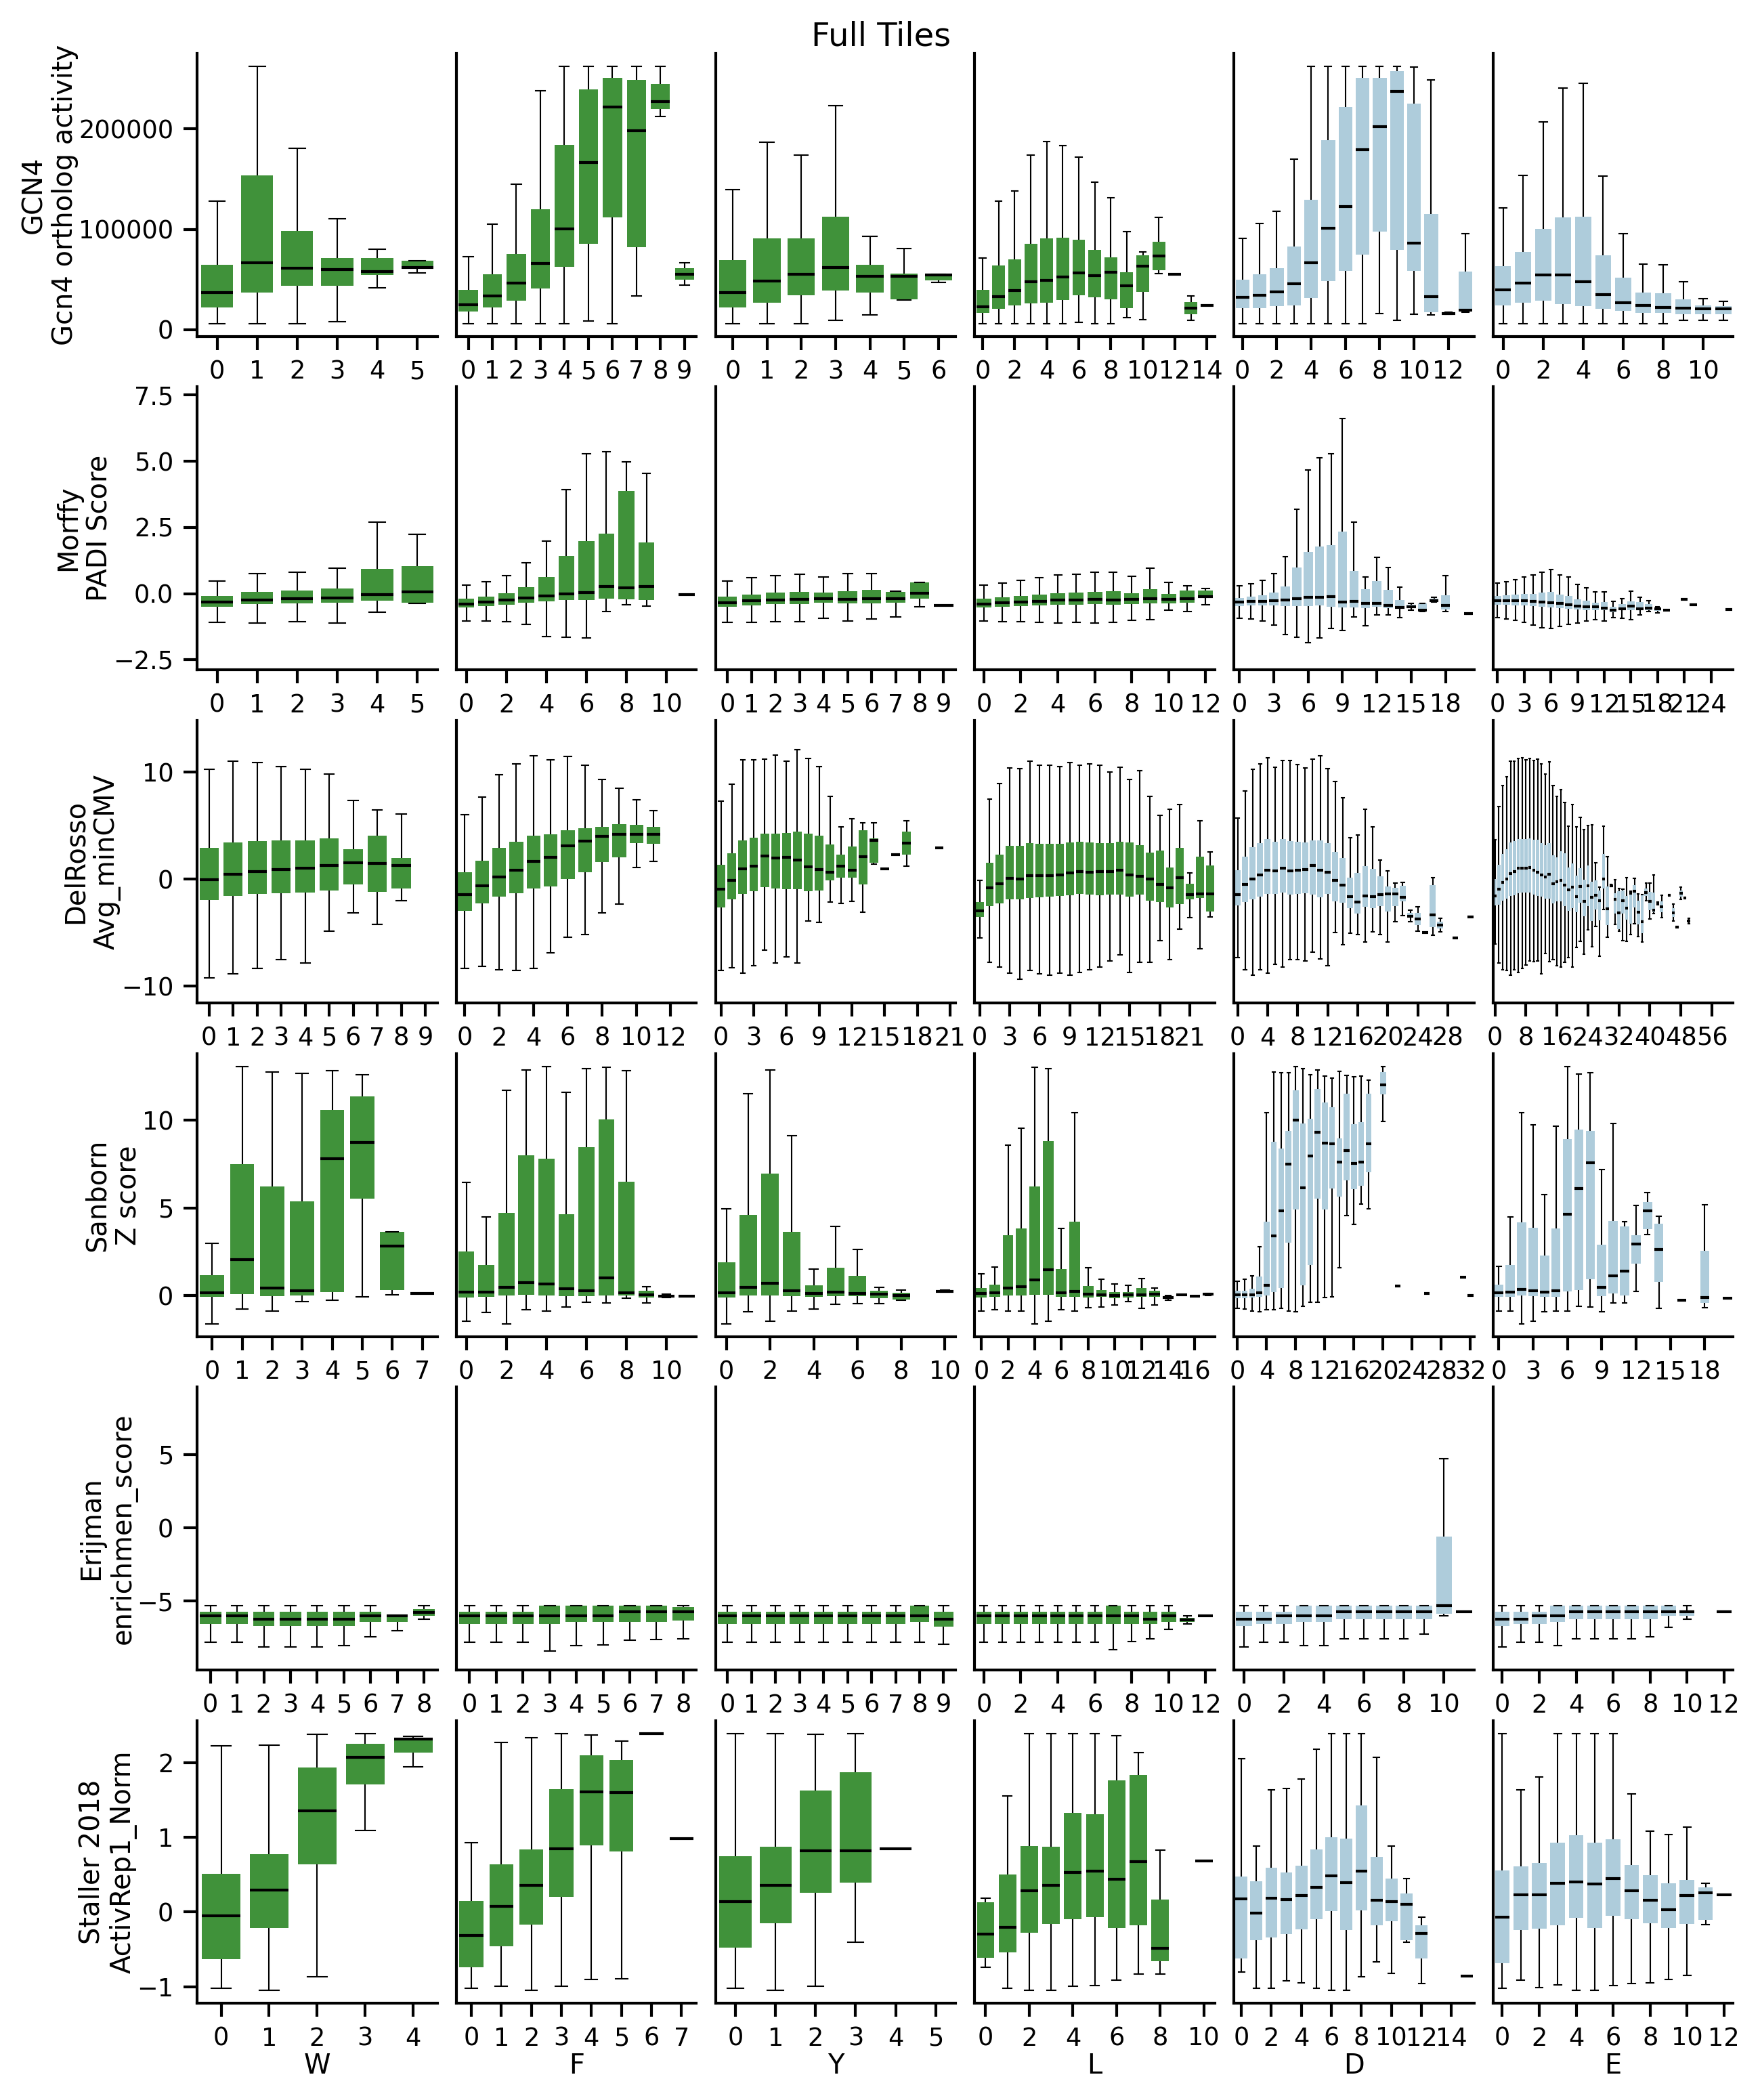

In [16]:
# Plot the libraries
plot_libraries_axis_swap(libraries, title = "Full Tiles")
